In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print(df.shape)
print(df.columns)

print(df.info())
print(df.describe())

(918, 12)
Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+

In [4]:
# Handling Missing values

print(df.isnull().sum())
print(df.duplicated().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
0


# EDA

HeartDisease
1    508
0    410
Name: count, dtype: int64
---------------------------


<Axes: xlabel='HeartDisease', ylabel='Count'>

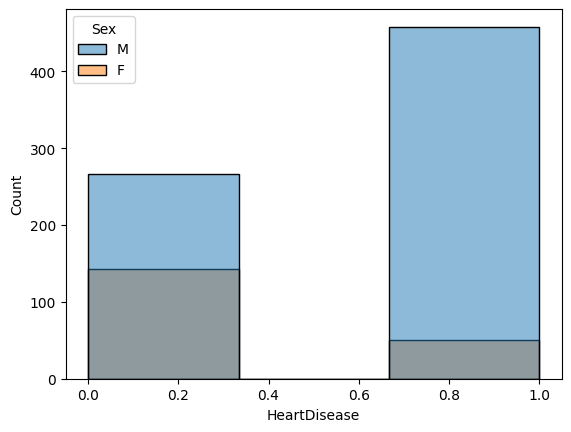

In [5]:
print(df['HeartDisease'].value_counts())
print("---------------------------")

sns.histplot(data=df,x="HeartDisease",bins=3,hue="Sex")

'Data mai RestingBP and Cholestrol dono ke value mai mistake hai 0 value jada hai mako eusko mean se fill karna padega'

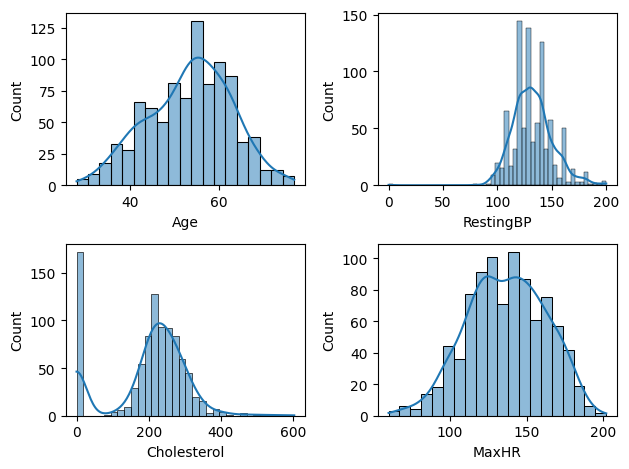

In [6]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(x=df[var],kde=True)

plotting("Age",1)
plotting("RestingBP",2)
plotting("Cholesterol",3)
plotting("MaxHR",4)

plt.tight_layout()
'''Data mai RestingBP and Cholestrol dono ke value mai mistake hai 0 value jada hai mako eusko mean se fill karna padega'''

In [7]:
# Cholesterol

print(df['Cholesterol'].value_counts())           # 172 values is 0
print("______________________________________")

cholestrol_mean = df.loc[df['Cholesterol']!=0,"Cholesterol"].mean()
print(cholestrol_mean)

print("____________________________")

df['Cholesterol'] = df['Cholesterol'].replace(0,cholestrol_mean)
print(df['Cholesterol'].value_counts())
df.head()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64
______________________________________
244.6353887399464
____________________________
Cholesterol
244.635389    172
254.000000     11
220.000000     10
223.000000     10
204.000000      9
             ... 
353.000000      1
278.000000      1
157.000000      1
176.000000      1
131.000000      1
Name: count, Length: 222, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [8]:
# RestingBP

print(df['RestingBP'].value_counts())  # BP SAI HAI

RestingBP_mean = df.loc[df['RestingBP']!=0,"RestingBP"].mean()
print(RestingBP_mean)

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
101      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64
132.54089422028352


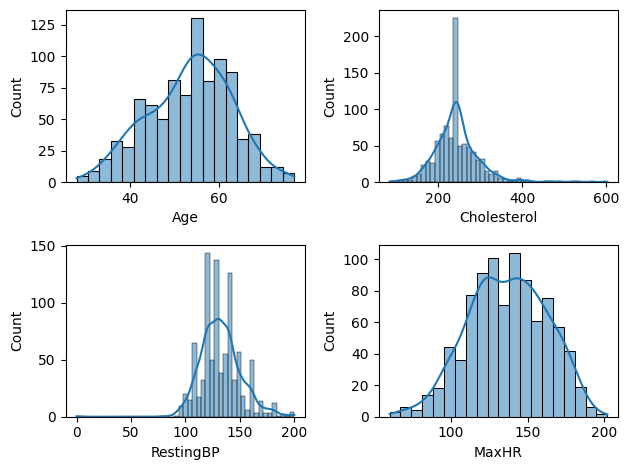

In [9]:
# Let's Try Again...
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(x=df[var],kde=True)

plotting("Age",1)
plotting("Cholesterol",2)
plotting("RestingBP",3)
plotting("MaxHR",4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

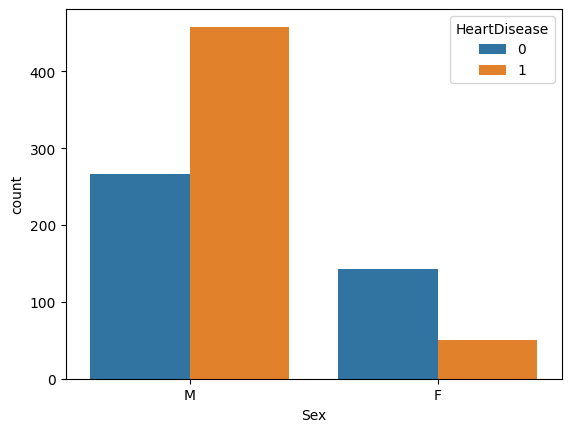

In [10]:
sns.countplot(x=df["Sex"],hue=df['HeartDisease'])

<Axes: xlabel='RestingECG', ylabel='count'>

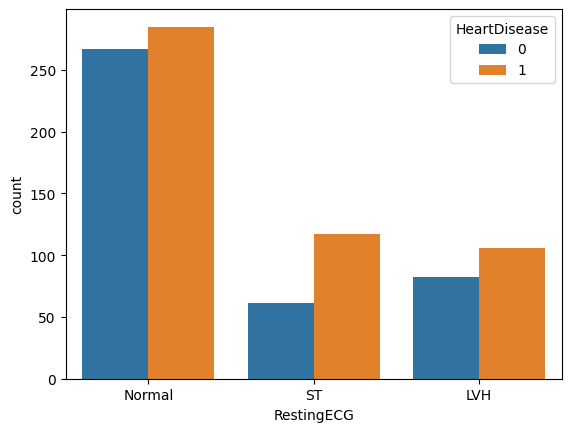

In [11]:
sns.countplot(x=df['RestingECG'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

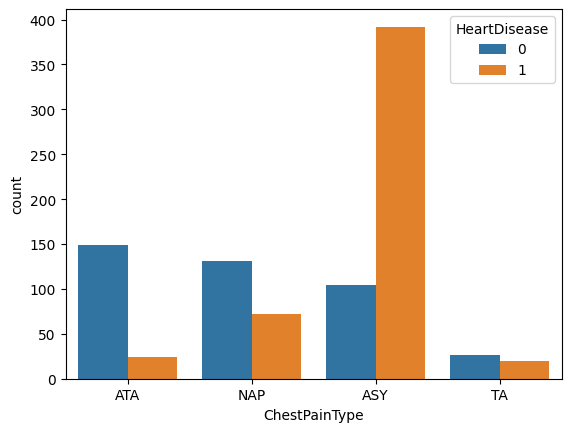

In [12]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

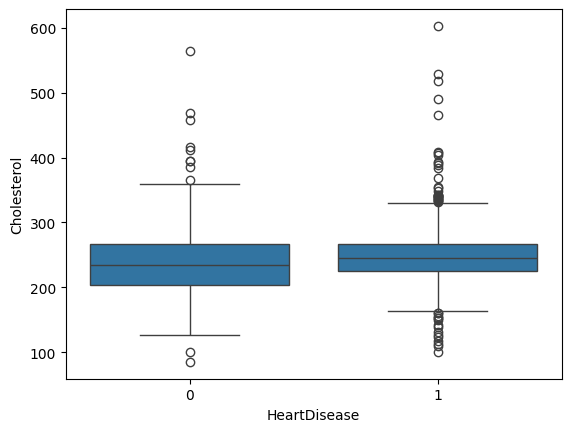

In [13]:
sns.boxplot(x=df['HeartDisease'],y=df['Cholesterol'])

<Axes: >

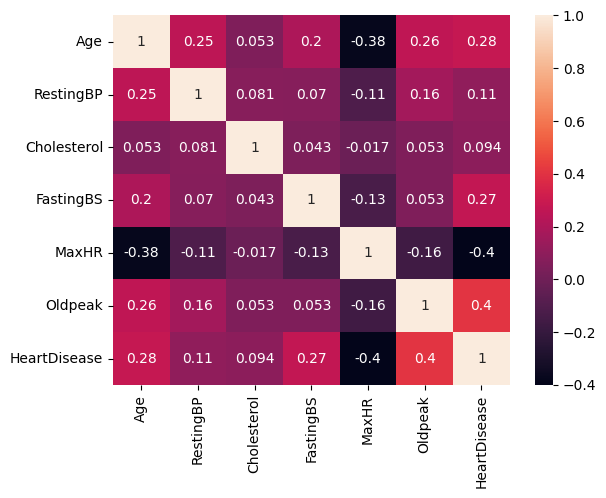

In [14]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

# Let's Performing ML Algorithm / Models

In [15]:
df_encode = pd.get_dummies(df)
df_encode = df_encode.astype(int)

df_encode.head()

print(df_encode.shape)
print(df_encode.columns)

(918, 21)
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [16]:
# Let's Time to Predict or Choose Accuarate Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,classification_report

In [17]:
x = df_encode.drop('HeartDisease',axis=1)
y = df_encode['HeartDisease']

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [18]:
scaler = StandardScaler()

x_train_scale = scaler.fit_transform(X_train)
x_test_scale = scaler.fit_transform(X_test)

In [19]:
models = {
    "LogisticRegression" : LogisticRegression(),
    "SVM" : SVC(),
    "K-NN" : KNeighborsClassifier(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Naive Bayes" : GaussianNB()
}
result = []

In [20]:
for name,model in models.items():
    model.fit(x_train_scale,y_train)
    y_pred = model.predict(x_test_scale)
    accuracy = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    result.append({
        "Model" : name,
        "Accuracy" : round(accuracy,3),
        "F1-Score" : round(f1,3),
    })

result  # Logistic Regression ka Model accha hai..

[{'Model': 'LogisticRegression', 'Accuracy': 0.875, 'F1-Score': 0.89},
 {'Model': 'SVM', 'Accuracy': 0.864, 'F1-Score': 0.88},
 {'Model': 'K-NN', 'Accuracy': 0.848, 'F1-Score': 0.865},
 {'Model': 'Decision Tree', 'Accuracy': 0.832, 'F1-Score': 0.846},
 {'Model': 'Naive Bayes', 'Accuracy': 0.832, 'F1-Score': 0.846}]

In [21]:
import joblib

joblib.dump(models['LogisticRegression'],"LR.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(x.columns.tolist(),"col.pkl")

['col.pkl']